# Week 11 - Introduction to Modeling, part 2

# 1. Lesson - No lesson this week

# 2. Weekly graph question

In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer
import matplotlib.pyplot as plt

The book names one of Vonnegut's rules as "keep it simple" and another as "have the guts to cut."  Here is some data from the previous week's lesson.  If you had to cut one of the two plots below, which would it be?  Which seems more interesting or important?  Explain.  (Should "amount of training data used" or "number of estimators" be on the x-axis.)

I would cut the first plot because the second better depicts the main curve of the plot without smaller upticks in the curve as distractors.   
The amount of training data should be on the x-axis due to the loss function being dependent on the amount.

In [2]:
np.random.seed(0)
num_points = 10000
feature_1a = np.random.random(size = num_points) * 3
feature_2a = np.random.random(size = num_points) * 3
feature_3a = np.random.random(size = num_points) * 3
train_target = (feature_1a - 2 * feature_2a) * feature_3a + np.random.normal(size = num_points)
feature_1b = np.random.random(size = num_points) * 3
feature_2b = np.random.random(size = num_points) * 3
feature_3b = np.random.random(size = num_points) * 3
test_target = (feature_1b - 2 * feature_2b) * feature_3b + np.random.normal(size = num_points)
train_df = pd.DataFrame({"f1": feature_1a, "f2": feature_2a, "f3": feature_3a})
test_df = pd.DataFrame({"f1": feature_1b, "f2": feature_2b, "f3": feature_3b})
rf = RandomForestRegressor()
rf.fit(train_df.values, train_target)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [3]:
rmse_lst = list()
rf = RandomForestRegressor()
for x in range(round(num_points / 20), num_points, round(num_points / 20)):
    rf.fit(train_df.values[0:x,:], train_target[0:x])
    rmse_lst.append(root_mean_squared_error(rf.predict(test_df.values), test_target))

import matplotlib.pyplot as plt

Text(0, 0.5, 'Loss function')

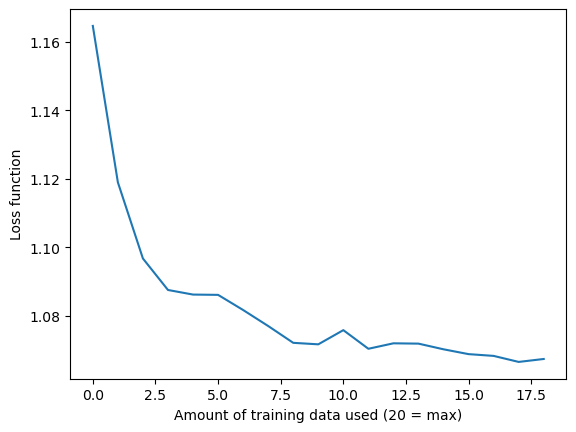

In [4]:
plt.plot(rmse_lst)
plt.xlabel("Amount of training data used (20 = max)")
plt.ylabel("Loss function")

In [5]:
num_trees_lst = list()
for n_estimators in range(1, 100, 3):
    rf = RandomForestRegressor(n_estimators = n_estimators)
    rf.fit(train_df.values, train_target)
    num_trees_lst.append(root_mean_squared_error(rf.predict(test_df.values), test_target))

Text(0, 0.5, 'Loss function')

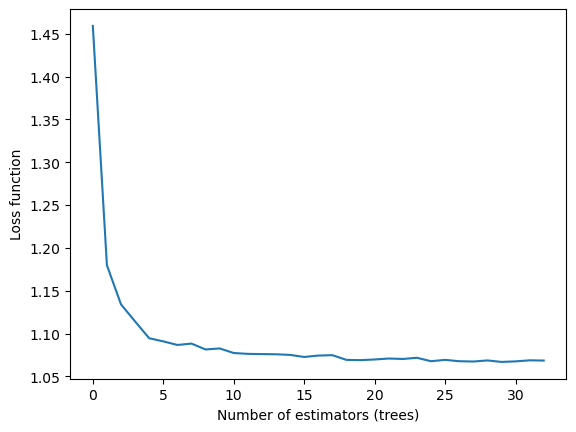

In [6]:
plt.plot(num_trees_lst)
plt.xlabel("Number of estimators (trees)")
plt.ylabel("Loss function")

# 3. Working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

Here are some types of analysis you can do:

* Implement a random forest model.
* Perform cross-validation.
* Tune hyperparameters.
* Evaluate a performance metric.

If you like, you can try other types of models, too (beyond linear regression and random forest) although you will have many opportunities to do that next semester.

**Import Add'l Libraries**

In [7]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import (RepeatedKFold, 
                                    StratifiedKFold,
                                    train_test_split, 
                                    cross_val_score)
import optuna
from optuna.visualization import plot_param_importances
from optuna.visualization import plot_optimization_history
from sklearn.metrics import classification_report, confusion_matrix

**Load Data**

In [8]:
diabetes_indicators = pd.read_csv('Modified_Datasets/diabetes_indicators.csv')
obesity = pd.read_csv('Modified_Datasets/obesity.csv')
cervical_cancer = pd.read_csv('Modified_Datasets/cervical_cancer.csv')

In [9]:
diabetes_indicators.columns

Index(['Diabetes_012', 'HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker',
       'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies',
       'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth',
       'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education',
       'Income'],
      dtype='object')

In [10]:
obesity.columns

Index(['Age (yrs)', 'Height (m)', 'Weight (kg)', 'Vegetables with Meals',
       '# of Main Meals/Day', 'Water/Day', 'Physical Activity',
       'Technology Time', 'Obesity Level', 'BMI', 'Gender_Male',
       'family_history_with_overweight_yes',
       'Frequent Caloric Food Intake_yes', 'Smoker_yes',
       'Calories Monitored_yes', 'Transportation Method_Bike',
       'Transportation Method_Motorbike',
       'Transportation Method_Public_Transportation',
       'Transportation Method_Walking', 'Snacking (Encoded)',
       'Alcohol Frequency (Encoded)'],
      dtype='object')

In [11]:
cervical_cancer.columns

Index(['Age', 'Number of sexual partners', 'First sexual intercourse',
       'Num of pregnancies', 'Smokes', 'Smokes (years)', 'Smokes (packs/year)',
       'Hormonal Contraceptives', 'Hormonal Contraceptives (years)', 'IUD',
       'IUD (years)', 'STDs', 'STDs (number)', 'STDs:condylomatosis',
       'STDs:cervical condylomatosis', 'STDs:vaginal condylomatosis',
       'STDs:vulvo-perineal condylomatosis', 'STDs:syphilis',
       'STDs:pelvic inflammatory disease', 'STDs:genital herpes',
       'STDs:molluscum contagiosum', 'STDs:AIDS', 'STDs:HIV',
       'STDs:Hepatitis B', 'STDs:HPV', 'STDs: Number of diagnosis',
       'STDs: Time since first diagnosis', 'STDs: Time since last diagnosis',
       'Dx:Cancer', 'Dx:CIN', 'Dx:HPV', 'Dx', 'Hinselmann', 'Schiller',
       'Citology', 'Biopsy'],
      dtype='object')

In [12]:
# Check for class imbalance in target

In [13]:
diabetes_indicators['Diabetes_012'].value_counts(normalize = True).sort_values()

Diabetes_012
1    0.020145
2    0.152741
0    0.827114
Name: proportion, dtype: float64

Moderate (15%) to severe (2%) imbalance

In [14]:
obesity['Obesity Level'].value_counts(normalize = True).sort_values()

Obesity Level
Insufficient_Weight    0.127935
Overweight_Level_I     0.132247
Normal_Weight          0.135122
Overweight_Level_II    0.138955
Obesity_Type_II        0.142310
Obesity_Type_III       0.155247
Obesity_Type_I         0.168184
Name: proportion, dtype: float64

Divided equally, each class should constitute ~14% of total proportion; no class imbalance

In [15]:
cervical_cancer['Dx:Cancer'].value_counts(normalize = True).sort_values()

Dx:Cancer
1    0.021557
0    0.978443
Name: proportion, dtype: float64

Severe (2%) class imbalance

**Implement Random Forest Model**

*Diabetes*

In [16]:
# Account for class imbalance in model
model1 = RandomForestClassifier(random_state = 42, class_weight = 'balanced_subsample')

In [17]:
X = diabetes_indicators.drop('Diabetes_012', axis = 1)
y = diabetes_indicators['Diabetes_012']

In [18]:
X_train_diabetes, X_test_diabetes, y_train_diabetes, y_test_diabetes = train_test_split(X, y, test_size = 0.2, random_state = 42)

*Obesity*

In [19]:
# Initialize model
model2 = RandomForestClassifier(random_state = 42)

In [20]:
X = obesity.drop('Obesity Level', axis = 1)
y = obesity['Obesity Level']

In [21]:
X_train_obesity, X_test_obesity, y_train_obesity, y_test_obesity = train_test_split(X, y, test_size = 0.2, random_state = 42)

*Cervical Cancer*

In [22]:
# Account for class imbalance
model3 = RandomForestClassifier(random_state = 42, class_weight = 'balanced_subsample')

In [23]:
X = cervical_cancer.drop('Dx:Cancer', axis = 1)
y = cervical_cancer['Dx:Cancer']

In [24]:
X_train_cancer, X_test_cancer, y_train_cancer, y_test_cancer = train_test_split(X, y, test_size = 0.2, random_state = 42)

**Perform Cross-Validation**

In [25]:
cv = RepeatedKFold(n_splits = 5, n_repeats = 5, random_state = 42)

*Diabetes*

In [26]:
# Scoring = recall_weighted to account for multiclass and class imbalance
cv_results_diabetes = cross_val_score(model1, 
                                      X_train_diabetes, 
                                      y_train_diabetes, 
                                      cv = cv,
                                     scoring = 'recall_weighted')

In [27]:
print(cv_results_diabetes.mean())

0.8245147476400431


*Obesity*

In [28]:
cv_results_obesity = cross_val_score(model2, 
                                      X_train_obesity, 
                                      y_train_obesity, 
                                      cv = cv,
                                     scoring = 'accuracy')

In [29]:
print(cv_results_obesity.mean())

0.9882569995144845


*Cervical Cancer*

In [30]:
# Changing cv to StratifiedKFold to address warning that some folds do not contain minority class
cv = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 42)

In [31]:
# Class is binary and recall accounts for minority class
cv_results_cancer = cross_val_score(model3, 
                                      X_train_cancer, 
                                      y_train_cancer, 
                                      cv = cv,
                                     scoring = 'recall')

In [32]:
print(cv_results_cancer.mean())

0.6666666666666666


**Tune Hyperparameters**

In [33]:
# Using Optuna

In [34]:
def objective_function(trial, X_train, y_train, scoring, class_weight):

    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 1500),
        'max_depth': trial.suggest_int('max_depth', 2, 100),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 30),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 30),
        'max_features': trial.suggest_float('max_features', 0.1, 1),
        'max_leaf_nodes': trial.suggest_int('max_leaf_nodes', 2, 1000),
        'min_impurity_decrease': trial.suggest_float('min_impurity_decrease', 1e-7, 1e-1, log = True),
        'class_weight': class_weight
    }

    model = RandomForestClassifier(**params)

    cv_scores = cross_val_score(model, X_train, y_train, cv = cv, scoring = scoring)

    return cv_scores.mean()

In [35]:
def createandrunstudy(X_train, y_train, scoring, class_weight, n_trials):
    
    study = optuna.create_study(direction = 'maximize')
    study.optimize(lambda trial: objective_function(trial, X_train, y_train, scoring, class_weight), n_trials = n_trials)
    results = study.trials_dataframe()
    results = results.sort_values('value', ascending = False)
    
    return results, study

*Diabetes*

In [36]:
results, study = createandrunstudy(X_train_diabetes, y_train_diabetes, 'recall_weighted', 'balanced_subsample', 75)

[I 2026-04-16 01:40:51,007] A new study created in memory with name: no-name-efb2f67c-b6dd-4340-ad96-8cbb2cb7dc28
[I 2026-04-16 01:45:03,630] Trial 0 finished with value: 0.6182490543296195 and parameters: {'n_estimators': 672, 'max_depth': 83, 'min_samples_split': 14, 'min_samples_leaf': 26, 'max_features': 0.4270372030963383, 'max_leaf_nodes': 717, 'min_impurity_decrease': 0.0018138717137733142}. Best is trial 0 with value: 0.6182490543296195.
[I 2026-04-16 01:58:30,299] Trial 1 finished with value: 0.6481743601344411 and parameters: {'n_estimators': 764, 'max_depth': 94, 'min_samples_split': 14, 'min_samples_leaf': 22, 'max_features': 0.840855349566145, 'max_leaf_nodes': 278, 'min_impurity_decrease': 2.632198726438305e-06}. Best is trial 1 with value: 0.6481743601344411.
[I 2026-04-16 02:12:02,365] Trial 2 finished with value: 0.65871705009822 and parameters: {'n_estimators': 905, 'max_depth': 59, 'min_samples_split': 8, 'min_samples_leaf': 12, 'max_features': 0.713310504066257, 'ma

In [37]:
display(results.sort_values(by = 'value', ascending = False).head(5))

,number,value,datetime_start,datetime_complete,duration,params_max_depth,params_max_features,params_max_leaf_nodes,params_min_impurity_decrease,params_min_samples_leaf,params_min_samples_split,params_n_estimators,state
39,39,0.698320,2026-04-16 11:18:02.498535,2026-04-16 11:23:24.776825,0 days 00:05:22.278290,97,0.116146,962,1.927582e-06,1,14,830,COMPLETE
72,72,0.698021,2026-04-16 14:00:55.382202,2026-04-16 14:02:54.646263,0 days 00:01:59.264061,94,0.130649,975,1.184385e-06,7,11,308,COMPLETE
69,69,0.696291,2026-04-16 13:43:48.976281,2026-04-16 13:48:33.670475,0 days 00:04:44.694194,97,0.129060,895,1.909112e-07,8,11,762,COMPLETE
43,43,0.696253,2026-04-16 11:46:34.618729,2026-04-16 11:51:51.517342,0 days 00:05:16.898613,86,0.100995,862,3.784822e-07,4,15,821,COMPLETE
73,73,0.695780,2026-04-16 14:02:54.647289,2026-04-16 14:05:04.686006,0 days 00:02:10.038717,97,0.180099,979,1.091420e-06,8,11,306,COMPLETE


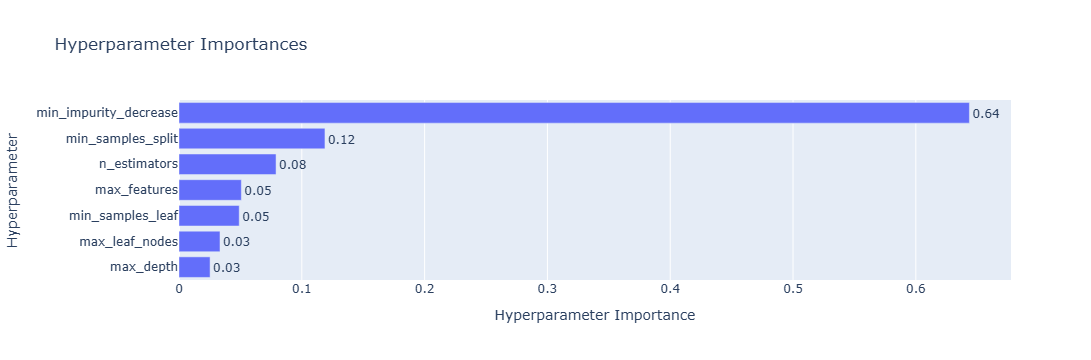

In [38]:
plot_param_importances(study)

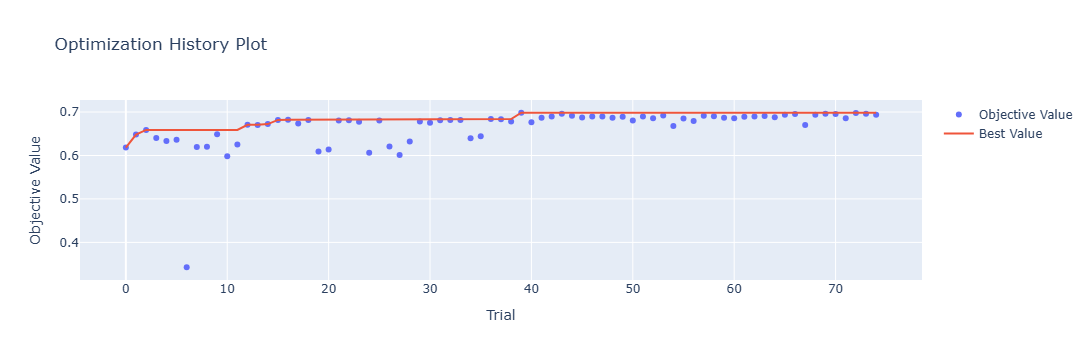

In [39]:
plot_optimization_history(study)

*Obesity*

In [40]:
results, study = createandrunstudy(X_train_obesity, y_train_obesity, 'accuracy', None, 25)

[I 2026-04-16 14:07:23,046] A new study created in memory with name: no-name-2b5cdbbb-87e1-457b-b9f7-f7fdbe37bad5
[I 2026-04-16 14:07:27,565] Trial 0 finished with value: 0.9047490604376831 and parameters: {'n_estimators': 705, 'max_depth': 4, 'min_samples_split': 13, 'min_samples_leaf': 3, 'max_features': 0.13810397006109898, 'max_leaf_nodes': 233, 'min_impurity_decrease': 1.8042360909639816e-07}. Best is trial 0 with value: 0.9047490604376831.
[I 2026-04-16 14:07:33,842] Trial 1 finished with value: 0.9185287083490676 and parameters: {'n_estimators': 964, 'max_depth': 70, 'min_samples_split': 24, 'min_samples_leaf': 24, 'max_features': 0.166347578577617, 'max_leaf_nodes': 991, 'min_impurity_decrease': 0.015657887946603624}. Best is trial 1 with value: 0.9185287083490676.
[I 2026-04-16 14:07:44,352] Trial 2 finished with value: 0.9694502886119652 and parameters: {'n_estimators': 1263, 'max_depth': 13, 'min_samples_split': 14, 'min_samples_leaf': 20, 'max_features': 0.24258100945996175

In [41]:
display(results.sort_values(by = 'value', ascending = False).head(5))

,number,value,datetime_start,datetime_complete,duration,params_max_depth,params_max_features,params_max_leaf_nodes,params_min_impurity_decrease,params_min_samples_leaf,params_min_samples_split,params_n_estimators,state
24,24,0.975435,2026-04-16 14:11:01.885799,2026-04-16 14:11:05.919901,0 days 00:00:04.034102,23,0.526996,537,0.000396,12,21,354,COMPLETE
22,22,0.974836,2026-04-16 14:10:53.814557,2026-04-16 14:10:58.470117,0 days 00:00:04.655560,25,0.517058,635,0.000005,10,27,401,COMPLETE
23,23,0.974237,2026-04-16 14:10:58.470117,2026-04-16 14:11:01.884296,0 days 00:00:03.414179,24,0.518863,557,0.000529,9,26,295,COMPLETE
19,19,0.974237,2026-04-16 14:10:38.874009,2026-04-16 14:10:39.698531,0 days 00:00:00.824522,21,0.657199,615,0.000020,7,27,58,COMPLETE
11,11,0.973638,2026-04-16 14:09:22.015956,2026-04-16 14:09:32.401325,0 days 00:00:10.385369,98,0.614013,807,0.000002,30,29,867,COMPLETE


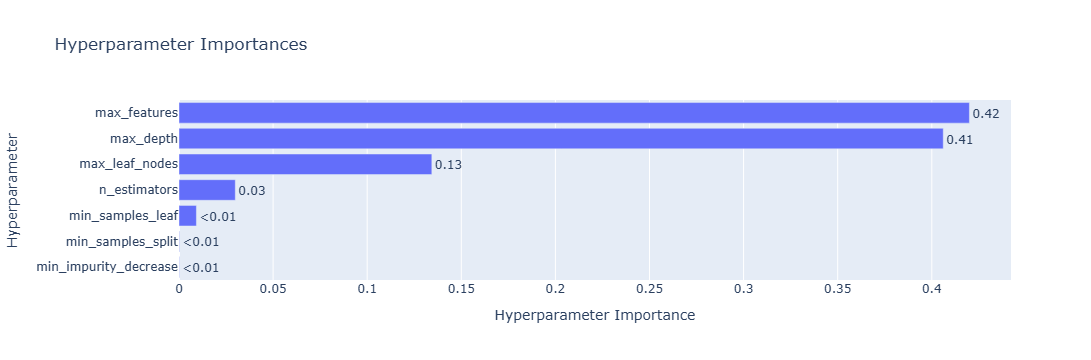

In [42]:
plot_param_importances(study)

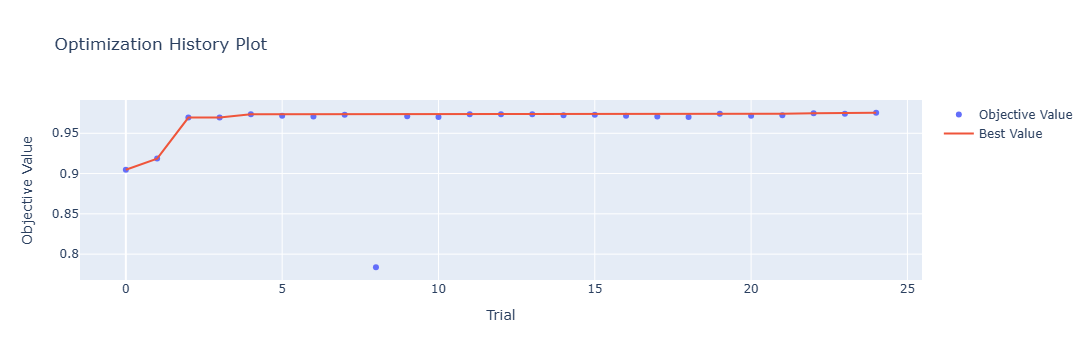

In [43]:
plot_optimization_history(study)

*Cervical Cancer*

In [44]:
results, study = createandrunstudy(X_train_cancer, y_train_cancer, 'recall', 'balanced_subsample', 15)

[I 2026-04-16 14:11:06,199] A new study created in memory with name: no-name-f7d8043f-3e70-457f-bb13-8677dae2dbb6
[I 2026-04-16 14:11:14,337] Trial 0 finished with value: 0.7333333333333332 and parameters: {'n_estimators': 1078, 'max_depth': 21, 'min_samples_split': 11, 'min_samples_leaf': 10, 'max_features': 0.6633763542583003, 'max_leaf_nodes': 414, 'min_impurity_decrease': 0.0001934711071883273}. Best is trial 0 with value: 0.7333333333333332.
[I 2026-04-16 14:11:16,072] Trial 1 finished with value: 0.4 and parameters: {'n_estimators': 223, 'max_depth': 16, 'min_samples_split': 10, 'min_samples_leaf': 29, 'max_features': 0.8713901506909753, 'max_leaf_nodes': 835, 'min_impurity_decrease': 0.0004232972210364532}. Best is trial 0 with value: 0.7333333333333332.
[I 2026-04-16 14:11:19,846] Trial 2 finished with value: 0.7333333333333332 and parameters: {'n_estimators': 536, 'max_depth': 17, 'min_samples_split': 27, 'min_samples_leaf': 9, 'max_features': 0.4377927445050772, 'max_leaf_nod

In [45]:
display(results.sort_values(by = 'value', ascending = False).head(5))

,number,value,datetime_start,datetime_complete,duration,params_max_depth,params_max_features,params_max_leaf_nodes,params_min_impurity_decrease,params_min_samples_leaf,params_min_samples_split,params_n_estimators,state
5,5,0.933333,2026-04-16 14:11:33.740904,2026-04-16 14:11:39.809452,0 days 00:00:06.068548,32,0.949310,702,0.000334,7,27,805,COMPLETE
10,10,0.933333,2026-04-16 14:12:16.530057,2026-04-16 14:12:23.507522,0 days 00:00:06.977465,49,0.973461,133,0.040628,3,15,929,COMPLETE
11,11,0.866667,2026-04-16 14:12:23.508535,2026-04-16 14:12:30.665563,0 days 00:00:07.157028,46,0.993946,158,0.090466,1,2,945,COMPLETE
12,12,0.866667,2026-04-16 14:12:30.666565,2026-04-16 14:12:38.602174,0 days 00:00:07.935609,55,0.987439,90,0.063599,1,15,1050,COMPLETE
13,13,0.866667,2026-04-16 14:12:38.603179,2026-04-16 14:12:42.919532,0 days 00:00:04.316353,2,0.644572,642,0.000023,5,25,602,COMPLETE


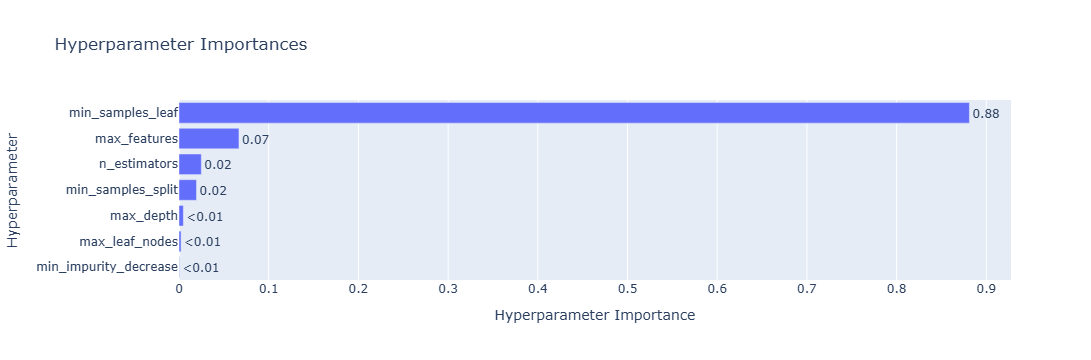

In [46]:
plot_param_importances(study)

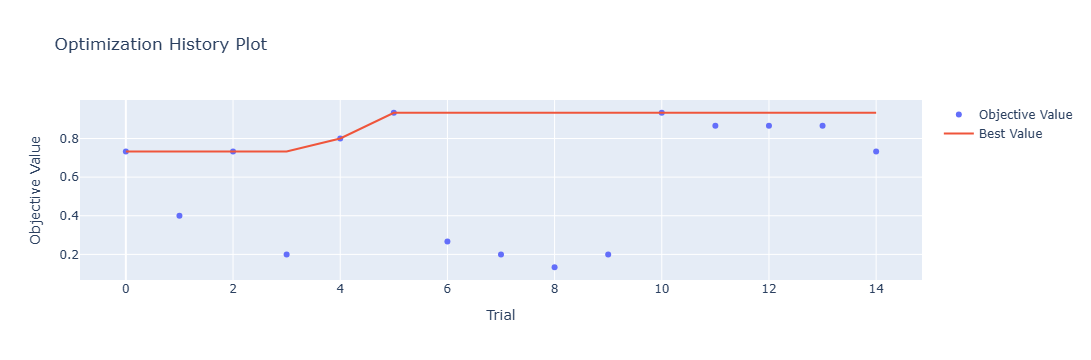

In [47]:
plot_optimization_history(study)

# 4. Storytelling With Data plot

Reproduce any graph of your choice in chapter seven (p. 165-185) of the Storytelling With Data book as best you can. You do not have to get the exact data values right, just the overall look and feel.

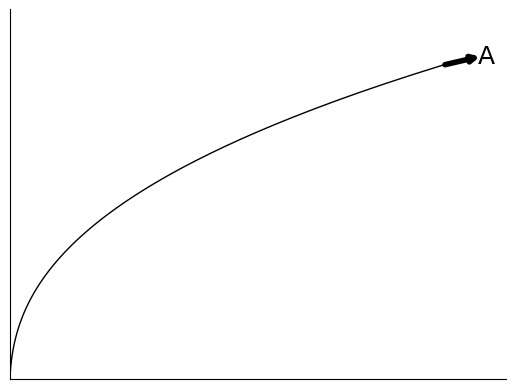

In [48]:
# Note: this is indeed from ch. 7

# Declare data
x = np.logspace(0, 3, 100)
y = x ** 0.4

# Plot
plt.plot(x, y, color = 'black', linewidth = 1)

# Add arrow
plt.annotate(
    "", 
    xy=(x[-1] + 20, y[-1]),      # arrow end
    xytext=(x[-2], y[-2]),  # arrow start (slightly before end)
    arrowprops=dict(arrowstyle="->", lw=4)
)

# Graph formatting

plt.xticks([], [])
plt.yticks([], [])

plt.xlim(1, 1070)
plt.ylim(0.9, 18)

plt.text(1010, 15.5, 'A', fontsize = 18, color = 'black')

ax = plt.gca()

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.show()